Trying a simple example of a transformer model. 

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import sys
sys.path.append('../')
from models.model import CrabTransformer
from models.losses import TweedieLoss
from data.data_helper import CrabDataset, get_dataloaders

In [ ]:
# Test the dataloader
# check the directory currently being used
import os

#os.chdir('..')  # Change this to your desired directory
print(f"Current working directory: {os.getcwd()}")
train_loader, val_loader, test_loader = get_dataloaders(batch_size=5)

# Get a batch
batch_x, batch_y, batch_years = next(iter(train_loader))

print(f"\nBatch shapes:")
print(f"  X (input): {batch_x.shape}")        # (5, 1, 50, 50)
print(f"  Y (target): {batch_y.shape}")       # (5, 1, 50, 50)
print(f"  Year indices: {batch_years.shape}") # (5,)
print(f"  Year indices: {batch_years}")       # e.g., tensor([12, 7, 23, 4, 19])

Current working directory: c:\Users\nmorok\Documents\Thesis\Teleconnections-ViT
Spawner norm: mean=56.8944, std=36.6632
Recruit norm: mean=49.6799, std=24.0246

Batch shapes:
  X (input): torch.Size([5, 1, 50, 50])
  Y (target): torch.Size([5, 1, 50, 50])
  Year indices: torch.Size([5])
  Year indices: tensor([16,  1, 28,  0, 18])


QUICK MODEL TEST

Device: cpu

[1/6] Loading data...
Spawner norm: mean=56.8944, std=36.6632
Recruit norm: mean=49.6799, std=24.0246
✓ Train batches: 440
✓ Val batches: 100
✓ Test batches: 60

[2/6] Getting test batch...
✓ Input shape: torch.Size([5, 1, 50, 50])
✓ Target shape: torch.Size([5, 1, 50, 50])
✓ Year indices: tensor([13, 26, 15,  3,  1])

[3/6] Creating model...
Sinusoidal temporal encoding initialized:
  Pre-computed years: 0-49
  Can dynamically compute beyond year 50 ✓
Initializing model weights...
✓ Weight initialization complete
✓ Total parameters: 1,303,233
✓ Trainable parameters: 1,303,233

[4/6] Testing forward pass...
✓ Output shape: torch.Size([5, 1, 50, 50])
✓ Output dtype: torch.float32
✓ Output range: [-21.2906, 25.4471]
✓ No NaN/Inf values

[5/6] Testing backward pass...
✓ Loss: 27.9658
  ⚠️  Large gradient in transformer_blocks.0.attention.W_v.weight: 214.89
  ⚠️  Large gradient in transformer_blocks.0.attention.W_o.weight: 248.80
  ⚠️  Large gradient in trans

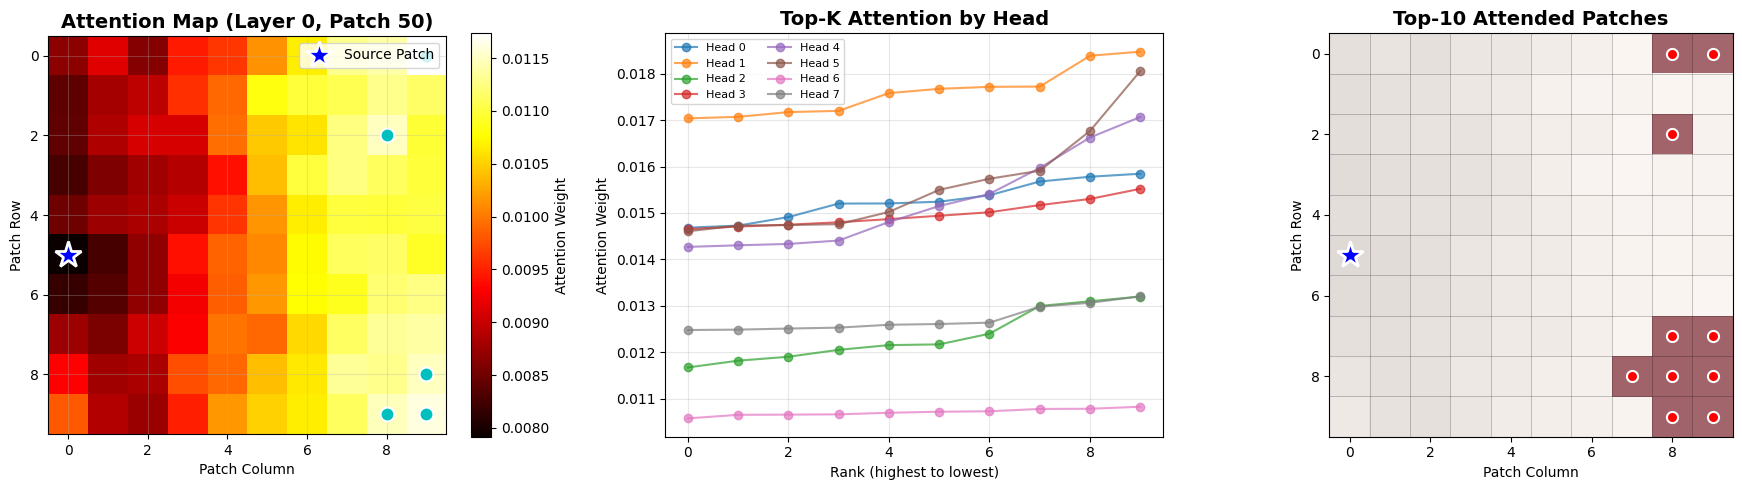

In [4]:
import torch
import torch.nn as nn
import os
import matplotlib.pyplot as plt
import numpy as np

def quick_model_test():
    """
    Quick sanity check before training.
    Tests: data loading, forward pass, backward pass, shapes, gradients.
    """
    print("="*80)
    print("QUICK MODEL TEST")
    print("="*80)
    
    # Setup
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"\nDevice: {device}")
    
    # 1. Load data
    print("\n[1/6] Loading data...")
    from data.data_helper import get_dataloaders
    train_loader, val_loader, test_loader = get_dataloaders(batch_size=5)
    print(f"✓ Train batches: {len(train_loader)}")
    print(f"✓ Val batches: {len(val_loader)}")
    print(f"✓ Test batches: {len(test_loader)}")
    
    # 2. Get a batch
    print("\n[2/6] Getting test batch...")
    batch_x, batch_y, batch_years = next(iter(train_loader))
    print(f"✓ Input shape: {batch_x.shape}")        # (5, 1, 50, 50)
    print(f"✓ Target shape: {batch_y.shape}")       # (5, 1, 50, 50)
    print(f"✓ Year indices: {batch_years}")         # tensor([...])
    
    # 3. Create model
    print("\n[3/6] Creating model...")
    from models.model import CrabTransformer
    model = CrabTransformer(
        grid_size=50,
        patch_size=5,
        in_channels=1,
        embed_dim=128,
        num_heads=8,
        num_layers=6,
        d_ff=512,
        dropout=0.1
    ).to(device)
    
    # Count parameters
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"✓ Total parameters: {total_params:,}")
    print(f"✓ Trainable parameters: {trainable_params:,}")
    
    # 4. Forward pass
    print("\n[4/6] Testing forward pass...")
    batch_x = batch_x.to(device)
    batch_y = batch_y.to(device)
    batch_years = batch_years.to(device)
    
    model.eval()  # Set to eval mode first
    with torch.no_grad():
        predictions = model(batch_x, batch_years)
    
    print(f"✓ Output shape: {predictions.shape}")   # Should be (5, 1, 50, 50)
    print(f"✓ Output dtype: {predictions.dtype}")
    print(f"✓ Output range: [{predictions.min():.4f}, {predictions.max():.4f}]")
    
    # Check for NaNs/Infs
    if torch.isnan(predictions).any():
        print("❌ WARNING: NaN values in output!")
        return False
    if torch.isinf(predictions).any():
        print("❌ WARNING: Inf values in output!")
        return False
    print("✓ No NaN/Inf values")
    
    # 5. Test loss and backward pass
    print("\n[5/6] Testing backward pass...")
    model.train()  # Set to training mode
    criterion = nn.MSELoss()
    
    # Forward
    predictions = model(batch_x, batch_years)
    loss = criterion(predictions, batch_y)
    print(f"✓ Loss: {loss.item():.4f}")
    
    # Backward
    loss.backward()
    
    # Check gradients
    grad_norms = []
    for name, param in model.named_parameters():
        if param.grad is not None:
            grad_norm = param.grad.norm().item()
            grad_norms.append(grad_norm)
            if grad_norm > 100:
                print(f"  ⚠️  Large gradient in {name}: {grad_norm:.2f}")
    
    avg_grad_norm = np.mean(grad_norms)
    max_grad_norm = np.max(grad_norms)
    print(f"✓ Average gradient norm: {avg_grad_norm:.4f}")
    print(f"✓ Max gradient norm: {max_grad_norm:.4f}")
    
    if max_grad_norm > 1000:
        print("❌ WARNING: Very large gradients detected!")
        return False
    
    # 6. Test attention visualization
    print("\n[6/6] Testing attention visualization...")
    model.eval()
    with torch.no_grad():
        predictions, attention_maps = model(batch_x, batch_years, return_attention=True)
    
    print(f"✓ Number of attention maps (layers): {len(attention_maps)}")
    print(f"✓ Attention map shape: {attention_maps[0].shape}")  # (batch, heads, patches, patches)
    
    # Test visualization function
    try:
        fig = model.visualize_attention(
            attention_maps=attention_maps,
            layer_idx=0,  # First transformer layer
            sample_idx=0,  # First sample in batch
            patch_idx=50,  # Center patch
            save_path='test_attention.png'
        )
        print(f"✓ Attention visualization saved: test_attention.png")
    except Exception as e:
        print(f"⚠️  Attention visualization failed: {e}")
    
    # 7. Summary
    print("\n" + "="*80)
    print("TEST SUMMARY")
    print("="*80)
    print("✅ All tests passed!")
    print("\nYour model is ready to train. Recommended next steps:")
    print("1. Start with a small number of epochs (e.g., 3-5)")
    print("2. Monitor gradient norms during training")
    print("3. Check loss decreases over time")
    print("4. Visualize predictions after 1 epoch to check sanity")
    
    return True


if __name__ == "__main__":
    # Change to project root directory if needed
    import os
    if os.path.basename(os.getcwd()) == 'notebooks':
        os.chdir('..')
    
    success = quick_model_test()
    
    if not success:
        print("\n❌ Tests failed. Fix issues before training!")
    else:
        print("\n🚀 Ready to train!")